# The DynaDeep case
## Using petrophysics and adding salinity to ERT inversion
Minimal working example for the pygimli workshop

In [1]:
import numpy as np
import pygimli as pg
from pygimli.physics import ert

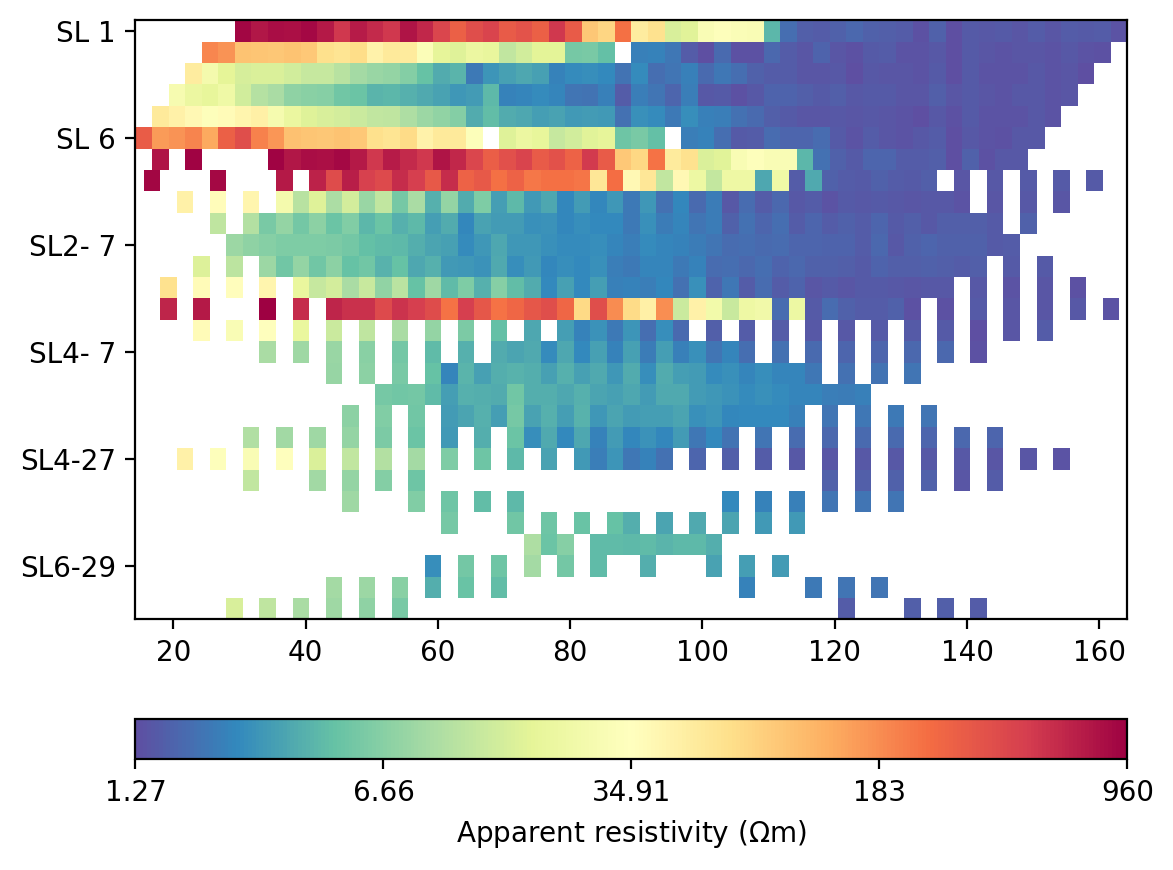

In [9]:
# %% Part 1/5: Data import
data = pg.DataContainerERT()
data.load('data.dat')
# I like this much more
data = ert.load('data.dat')
print(data)
# pg.show(data)
data.show(); # 'u', 'i' etc.
# return ax, cb and do some manipulations

### Part 2: Error estimation

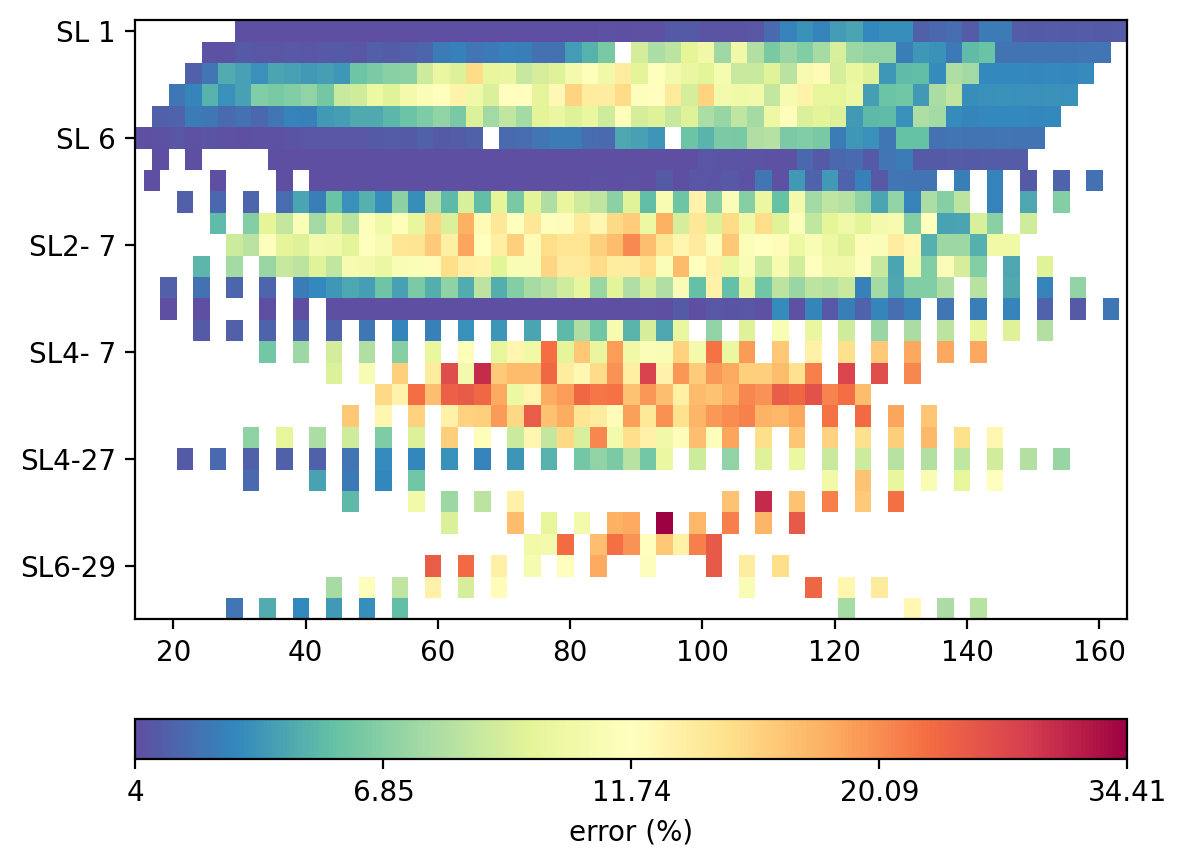

In [20]:
# data['err'] = ert.estimateError(data,
data.estimateError(
    relativeError=0.04,
    absoluteUError=5e-5)
data.show(data['err']*100, label='error (%)');

### Part 3: Manager and mesh

16/02/25 - 22:02:20 - pyGIMLi - INFO - Found 2 regions.
16/02/25 - 22:02:20 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
16/02/25 - 22:02:20 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/02/25 - 22:02:20 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/02/25 - 22:02:20 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 9856 Cells: 19204 Boundaries: 14656


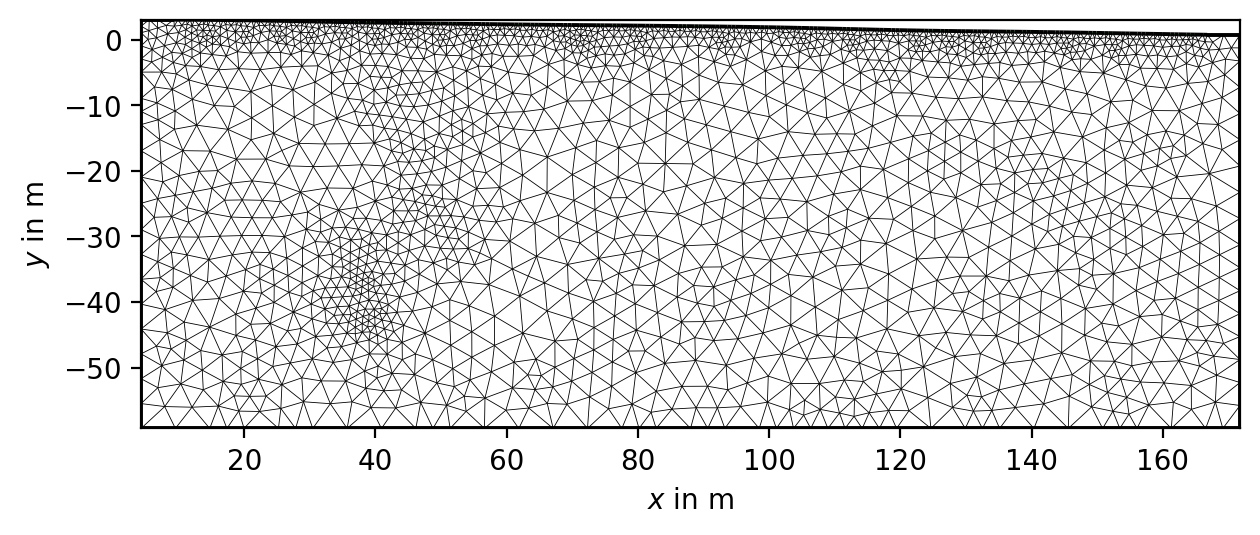

In [16]:
# %% Part 3/5: ERT Manager
mgr = ert.ERTManager(data)
mesh = mgr.createMesh(# **mesh_param)
    paraDepth=60,  # add line by line
    paraDX=0.25,
    paraMaxCellSize=10,
    quality=34.4,
)
# mgr.setMesh(mesh)  # already done
pg.show(mgr.paraDomain);  # inversion region
# pg.show(mesh) # show that it is part of bigger mesh

### Part 4: Inversion

In [17]:
# %% Part 4/5: Inversion
mgr.inv.setRegularization(2, zWeight=0.1)
# inv_param = {'lam': 20,
#              'startmodel': np.median(data["rhoa"])}
mgr.invert(verbose=True)

16/02/25 - 22:02:50 - pyGIMLi - INFO - Use median(data values)=3.06844394897819
16/02/25 - 22:02:50 - pyGIMLi - INFO - Created startmodel from forward operator:3589, min/max=3.068444/3.068444
16/02/25 - 22:02:50 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000027DC2DEA250>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation (cumulative):
	 0 Logarithmic LU transform, lower bound 0.0, upper bound 0.0
min/max (data): 1.27/960
min/max (error): 4%/34.41%
min/max (start model): 3.07/3.07
--------------------------------------------------------------------------------
inv.iter 0 ... chi² = 2036.00
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  180.41 (dPhi = 91.09%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =  129.28 (dPhi = 28.27%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =  105.11 (dPhi = 18.59%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =   71.24 (dPhi = 32.00%) lam: 2

3589 [3406.4384263741813,...,6.616154092384028]

### Part 5: save

16/02/25 - 22:08:28 - pyGIMLi - INFO - Saving inversion results to: .\20250216-22.08\ERTManager


('.\\20250216-22.08\\ERTManager',
 <Figure size 3200x2000 with 2 Axes>,
 <Axes: xlabel='$x$ in m', ylabel='$y$ in m'>)

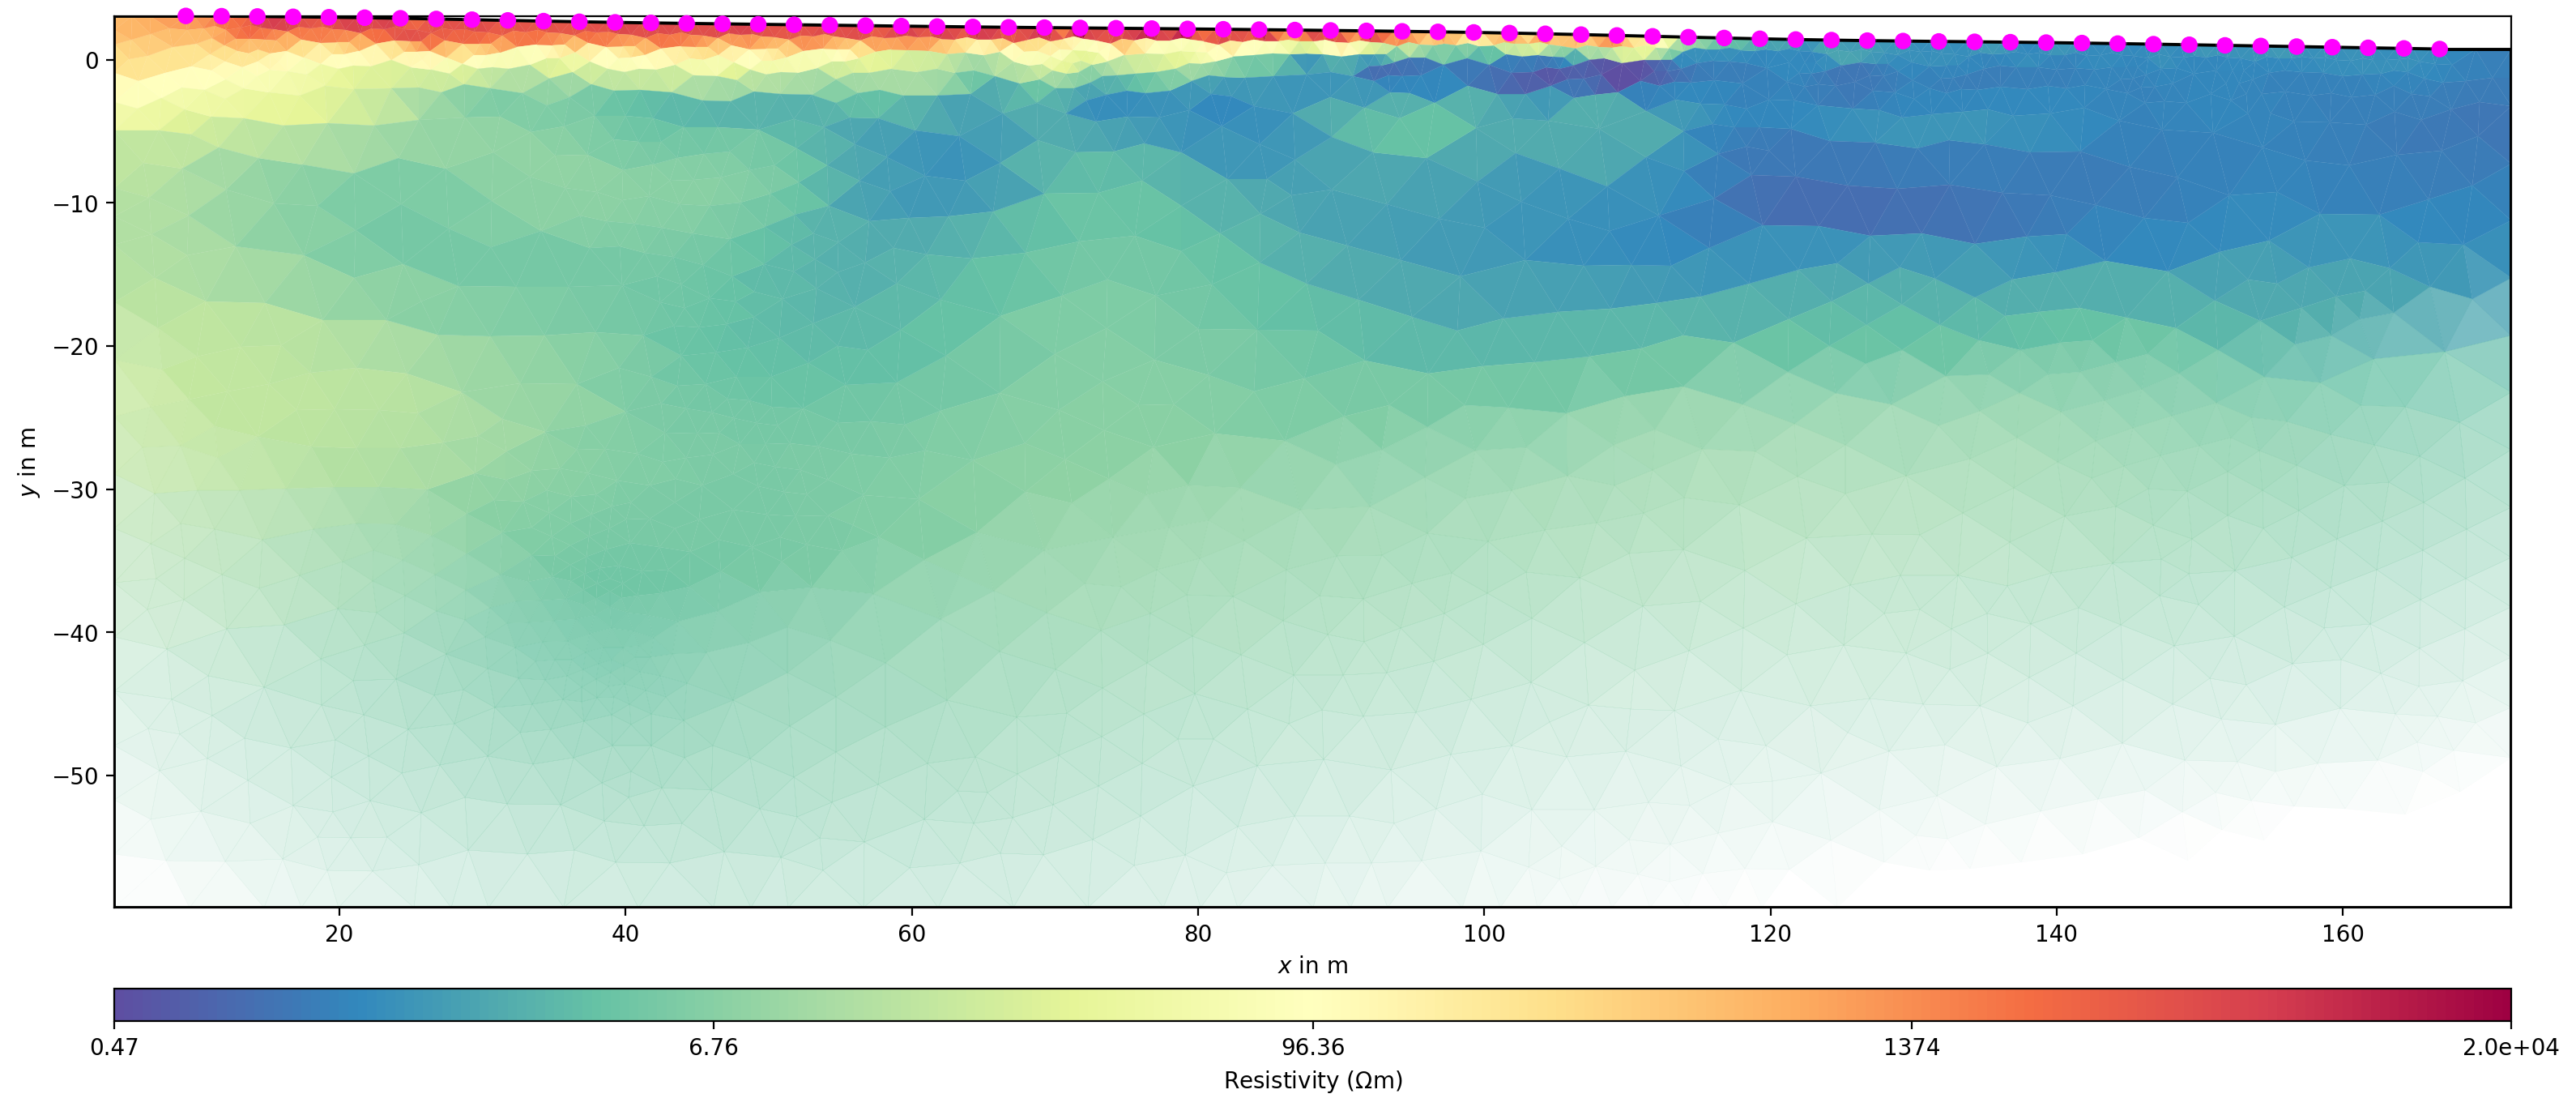

In [22]:
mgr.saveResult() # does it all in Ascii

In [21]:
# %% Part 5/5: Save model, response and coverage
results = {
    'model': mgr.model.array(),
    'coverage': mgr.coverage(),
    'response': mgr.inv.response.array(),
    'chi2': mgr.inv.inv.getChi2(),
    'rrms': mgr.inv.relrms(),
    'error': data['err']
    }
np.savez('ert_example1.npz', **results) # don't like it
mgr.paraDomain.save('mesh_example1.bms')

1